# TORNADIC CASE PROCESS

The new case parameters are as follows:
Near-Field: Within 21 km
Far-Field: Beyond 30 km
Tor: Within 30 minutes of first tornado report
Pretor: Before the hour before first tornado report (changed to be only positive delta time, so only before torgen)

In [1]:
from new_case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [70]:
storm_id = 8,14,18, 31,43, 55, 65
meso_id = 8,16, 36, 57

In [71]:
d = '20230527'
ka = 'ka1'
Ka = 'Ka1'
weights = [0.05, 0.2, 0.5, 0.2, 0.05]

In [72]:
tobac_features_xr_refl = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_refl.nc')
tobac_df_refl = tobac_id(tobac_features_xr_refl, storm_id)
latitude_weighted_tobac, longitude_weighted_tobac, storm_bearing, storm_speed, storm_times = storm_speed_and_bearing(tobac_df_refl, weights)

tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)

In [73]:
#grib_nc = xr.open_dataset(f'/Users/juliabman/Desktop/concat_test/{d}_grib.nc')
#lats, lons, times, shears = azshear_grib_variables(grib_nc)

# data that DOES depend on vads information
vads = sorted(glob.glob(f'/Volumes/Buhrman_4TB/dealiased_data/{d}/{ka}/*.nc'))
print(f'The number of VADs for {d} {Ka} is: {np.shape(vads)} VADs')
gps = pd.read_csv(f'/Volumes/Buhrman_4TB/product_raw/{ka}/GPS_{Ka}_{d}.txt', dtype='str')

easterlies_vads, westerlies_vads, secondtrip_vads = vads_sort(vads, gps)
print(f"""
The number of easterly VADs for {d} {Ka} is: {np.shape(easterlies_vads)} VADs
The number of westerly VADs for {d} {Ka} is: {np.shape(westerlies_vads)} VADs
The number of second trip VADs for {d} {Ka} is: {np.shape(secondtrip_vads)} VADs
""")

The number of VADs for 20230527 Ka1 is: (461,) VADs

The number of easterly VADs for 20230527 Ka1 is: (272,) VADs
The number of westerly VADs for 20230527 Ka1 is: (91,) VADs
The number of second trip VADs for 20230527 Ka1 is: (98,) VADs



In [74]:
vad_times, tobac_times, tobac_indeces, tobac_lats, tobac_lons = nearest_tobac_time(easterlies_vads, 
                                                                               np.array(latitude_weighted_tobac),
                                                                               np.array(longitude_weighted_tobac),
                                                                               storm_times[:-1])
storm_bearing_tobac_vads = storm_bearing[tobac_indeces]
storm_vel_tobac_vads = storm_speed[tobac_indeces]

meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
                                                                               np.array(latitude_weighted_tobac_meso),
                                                                               np.array(longitude_weighted_tobac_meso),
                                                                               meso_times[:-1])

meso_bearing_tobac_vads = meso_bearing[meso_indeces]
meso_vel_tobac_vads = meso_speed[meso_indeces]

vad_df = vad_df_new(easterlies_vads, gps, vad_times, tobac_times, tobac_indeces, tobac_lats, tobac_lons)

Get the max values over time of the target mesocyclones using the Features_shear dataset.

In [75]:
meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')

In [76]:
meso_stats

<xarray.Dataset>
Dimensions:          (index: 244)
Coordinates:
  * index            (index) int64 0 1 2 3 4 5 6 ... 237 238 239 240 241 242 243
Data variables: (12/14)
    frame            (index) int64 ...
    idx              (index) int64 ...
    hdim_1           (index) int64 ...
    hdim_2           (index) int64 ...
    num              (index) int64 ...
    threshold_value  (index) int64 ...
    ...               ...
    max              (index) float32 ...
    feature          (index) int64 ...
    time             (index) datetime64[ns] ...
    timestr          (index) <U19 ...
    latitude         (index) float64 ...
    longitude        (index) float64 ...

In [77]:
if not isinstance(meso_id, (list, set)):
    meso_id = [meso_id]
    
    meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)

meso_ids = meso_indeces.index


In [78]:
meso_ids

<xarray.DataArray 'index' (index: 27)>
array([ 12,  14,  19,  21,  25,  28,  31,  48,  55,  60,  73,  81,  92,  96,
       102, 121, 126, 131, 132, 141, 147, 158, 159, 192, 198, 228, 232])
Coordinates:
  * index    (index) int64 12 14 19 21 25 28 31 ... 147 158 159 192 198 228 232

In [79]:
if not isinstance(meso_ids, (list, set)):
    meso_ids = [meso_ids]
    
    meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)

meso_ids_stats = meso_indeces2.index


In [80]:
meso_ids_stats

<xarray.DataArray 'index' (index: 27)>
array([ 12,  14,  19,  21,  25,  28,  31,  48,  55,  60,  73,  81,  92,  96,
       102, 121, 126, 131, 132, 141, 147, 158, 159, 192, 198, 228, 232])
Coordinates:
  * index    (index) int64 12 14 19 21 25 28 31 ... 147 158 159 192 198 228 232

In [81]:
wanted_meso_max = meso_stats['max'][meso_ids_stats].values

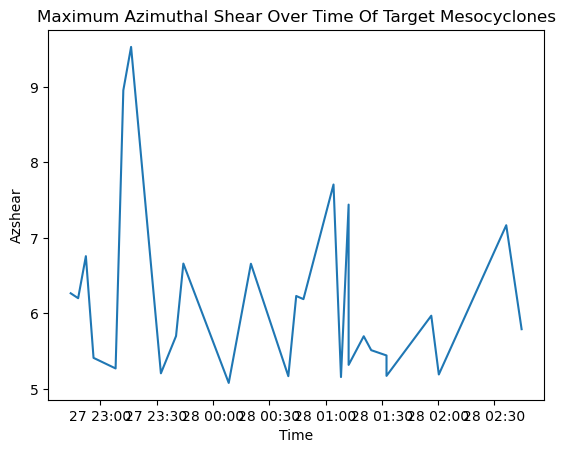

In [82]:
fig = plt.figure()
plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
plt.title('Maximum Azimuthal Shear Over Time Of Target Mesocyclones')
plt.xlabel('Time')
plt.ylabel('Azshear')
plt.show()

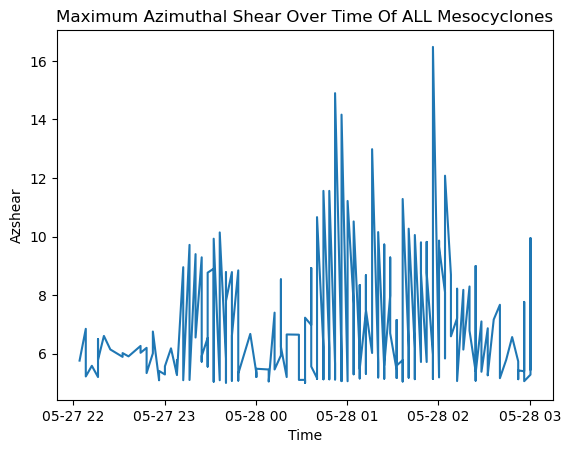

In [83]:
fig = plt.figure()
plt.plot(meso_stats['time'], meso_stats['max'].values)
plt.title('Maximum Azimuthal Shear Over Time Of ALL Mesocyclones')
plt.xlabel('Time')
plt.ylabel('Azshear')
plt.show()

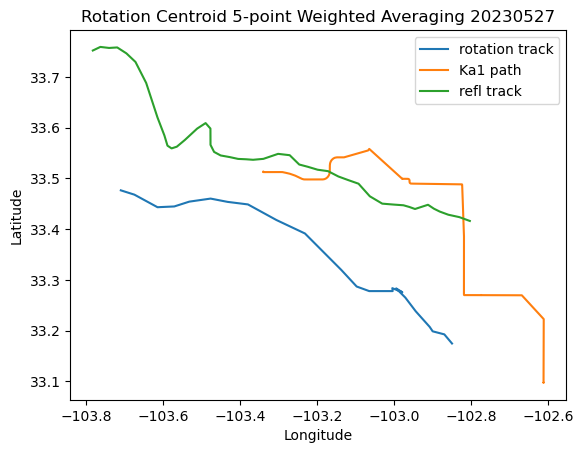

In [147]:
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

fig = plt.figure()
plt.plot(longitude_weighted_tobac_meso, latitude_weighted_tobac_meso)
plt.plot(vad_df.Lonmean, vad_df.Latmean)
#plt.plot(vad_df_ka2.Lonmean, vad_df_ka2.Latmean)
plt.plot(longitude_weighted_tobac, latitude_weighted_tobac)
plt.title(f'Rotation Centroid 5-point Weighted Averaging {d}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(['rotation track', f'{Ka} path', 'refl track'])
plt.show()

In [85]:
meso_to_ka_dist= []
meso_to_ka_bear = []
for i in range(len(meso_lats)):
    #print(rot_lats[i])
    fwd_az, back_az, distance = geodesic.inv(vad_df.Lonmean[i], vad_df.Latmean[i], meso_lons[i], meso_lats[i])
    # distance in m, az in degrees clockwise from N
    distance_km = distance / 1000
    meso_to_ka_dist.append(distance_km)
    meso_to_ka_bear.append(fwd_az)
    #storm_bearing_rot.append(fwd_az)

(272,)
(272,)


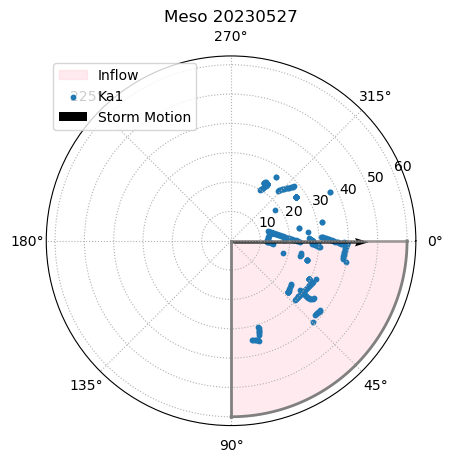

In [148]:
theta, r = polar_plot(f'Meso {d}', meso_to_ka_bear, storm_bearing_tobac_vads, meso_to_ka_dist, f'{Ka}')

In [87]:
theta_deg = theta * (180/np.pi)

In [88]:
inflow_vads, not_inflow_vads, nearfield_vads, farfield_vads, inflow_column, distance_column = inflow_near_far_test(storm_bearing_tobac_vads, theta_deg, easterlies_vads, meso_to_ka_dist, 360, 0)

19.94685784436112
41
20.318941311880923
42
20.72031650157955
43
18.126516627074643
195
18.12656310117005
196
18.126062385417338
197
13.064196043519775
198
12.88891395640218
199
12.72947107530516
200
12.585488866937538
201
12.447807375039535
202
12.320349960430528
203
12.222118681412002
204
12.240787010627706
205
12.44563639734523
206
12.741370249054802
207
13.104713220884134
208
13.475779910980833
209
13.873018002854678
210
14.314914258152832
211
12.983941620205346
212
13.189782320662864
213
13.399175098957272
214
13.58355212756441
215
13.749440565286609
216
14.026506995608871
217
14.219604134569474
218
14.26425486748296
219
14.263591626017229
220
14.260775234017295
221
14.258110222964124
222
14.259714176567718
223
14.259714176567718
223
14.259714176567718
223
14.259714176567718
223
14.259609842801076
227
14.259578542716241
228
14.25966853780822
229
14.304318267123667
230
14.503988027470042
231
14.770719440669541
232
15.050600343251618
233
15.374363111149533
234
15.678318107368709
235


In [89]:
original_list = nearfield_vads
nearfield_vads = list(dict.fromkeys(original_list))
np.shape(nearfield_vads)

(54,)

In [90]:
og = farfield_vads
farfield_vads = list(dict.fromkeys(og))
np.shape(farfield_vads)

(92,)

In [91]:
vad_df['Inflow'] = inflow_column
vad_df['Distance'] = distance_column
vad_df['Angle'] = theta_deg

In [92]:
data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')
tor_df, tor_nontor = tor_id(vad_df, data, str('Tornado'), str('PLAINS YOAKUM CO ARP'), str('US/Central'), False)
vad_df['Tor Times'] = tor_df
vad_df['Tor or Nontor'] = tor_nontor

1926 PLAINS YOAKUM CO ARP
2023-05-27 19:26:00
2023-05-28 01:26:00+00:00


In [93]:
vad_df['Tor or Nontor'].value_counts()

Tor or Nontor
pre tor    214
x           52
tor          6
Name: count, dtype: int64

In [94]:
vad_df.Inflow.value_counts()

Inflow
x            123
Farfield      92
Nearfield     57
Name: count, dtype: int64

In [95]:
vad_df.to_csv(f'case_dfs/new/{d}_{ka}_vad_df.csv', index=False)

In [96]:
tor_nf_vads_loc = vad_df[vad_df['Tor or Nontor'] == 'tor'][vad_df['Inflow'] == 'Nearfield']
id = tor_nf_vads_loc.index.values
tor_nearfield_vads = [easterlies_vads[i] for i in id]

nontor_nf_vads_loc = vad_df[vad_df['Tor or Nontor'] == 'pre tor'][vad_df['Inflow'] == 'Nearfield']
id = nontor_nf_vads_loc.index.values
nontor_nearfield_vads = [easterlies_vads[i] for i in id]

tor_ff_vads_loc = vad_df[vad_df['Tor or Nontor'] == 'tor'][vad_df['Inflow'] == 'Farfield']
id = tor_ff_vads_loc.index.values
tor_farfield_vads = [easterlies_vads[i] for i in id]

nontor_ff_vads_loc = vad_df[vad_df['Tor or Nontor'] == 'pre tor'][vad_df['Inflow'] == 'Farfield']
id = nontor_ff_vads_loc.index.values
nontor_farfield_vads = [easterlies_vads[i] for i in id]

In [97]:
tor_nearfield_vads = list(dict.fromkeys(tor_nearfield_vads))

nontor_nearfield_vads = list(dict.fromkeys(nontor_nearfield_vads))

tor_farfield_vads = list(dict.fromkeys(tor_farfield_vads))

nontor_farfield_vads = list(dict.fromkeys(nontor_farfield_vads))
np.shape(nontor_farfield_vads)

(60,)

In [98]:
np.shape(tor_nearfield_vads)

(6,)

In [99]:
np.shape(nontor_nearfield_vads)

(51,)

In [100]:
np.shape(tor_farfield_vads)

(0,)

In [101]:
tor_nearfield_vad_times, tor_nearfield_times, tor_nearfield_indeces, tor_nearfield_lats, tor_nearfield_lons = nearest_tobac_time(tor_nearfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])
tor_nearfield_bearing = storm_bearing[tor_nearfield_indeces]
tor_nearfield_velocity = storm_speed[tor_nearfield_indeces]

In [102]:
tor_farfield_vad_times, tor_farfield_times, tor_farfield_indeces, tor_farfield_lats, tor_farfield_lons = nearest_tobac_time(tor_farfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])
tor_farfield_bearing = storm_bearing[tor_farfield_indeces]
tor_farfield_velocity = storm_speed[tor_farfield_indeces]

In [103]:
nontor_nearfield_vad_times, nontor_nearfield_times, nontor_nearfield_indeces, nontor_nearfield_lats, nontor_nearfield_lons = nearest_tobac_time(nontor_nearfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])
nontor_nearfield_bearing = storm_bearing[nontor_nearfield_indeces]
nontor_nearfield_velocity = storm_speed[nontor_nearfield_indeces]

In [104]:
nontor_farfield_vad_times, nontor_farfield_times, nontor_farfield_indeces, nontor_farfield_lats, nontor_farfield_lons = nearest_tobac_time(nontor_farfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])
nontor_farfield_bearing = storm_bearing[nontor_farfield_indeces]
nontor_farfield_velocity = storm_speed[nontor_farfield_indeces]

In [129]:
tor_nearfield_u, tor_nearfield_v, tor_nearfield_heights = composite_u_and_v(tor_nearfield_vads[3:], gps, tor_nearfield_velocity, tor_nearfield_bearing)

In [106]:
nontor_nearfield_u, nontor_nearfield_v, nontor_nearfield_heights = composite_u_and_v(nontor_nearfield_vads, gps, nontor_nearfield_velocity, nontor_nearfield_bearing)

In [107]:
tor_farfield_u, tor_farfield_v, tor_farfield_heights = composite_u_and_v(tor_farfield_vads, gps, tor_farfield_velocity, tor_farfield_bearing)

UnboundLocalError: local variable 'vad_height' referenced before assignment

In [108]:
nontor_farfield_u, nontor_farfield_v, nontor_farfield_heights = composite_u_and_v(nontor_farfield_vads, gps, nontor_farfield_velocity, nontor_farfield_bearing)

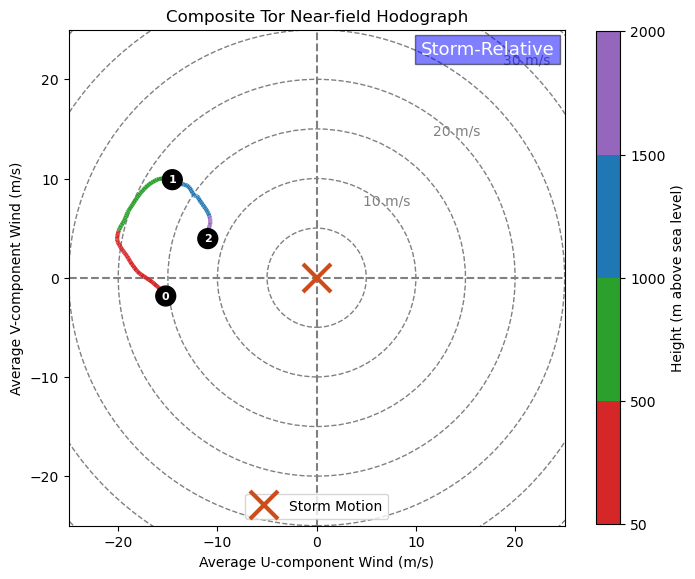

In [130]:
hodo_plot(tor_nearfield_u, tor_nearfield_v, tor_nearfield_heights, 25, 'Composite Tor Near-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

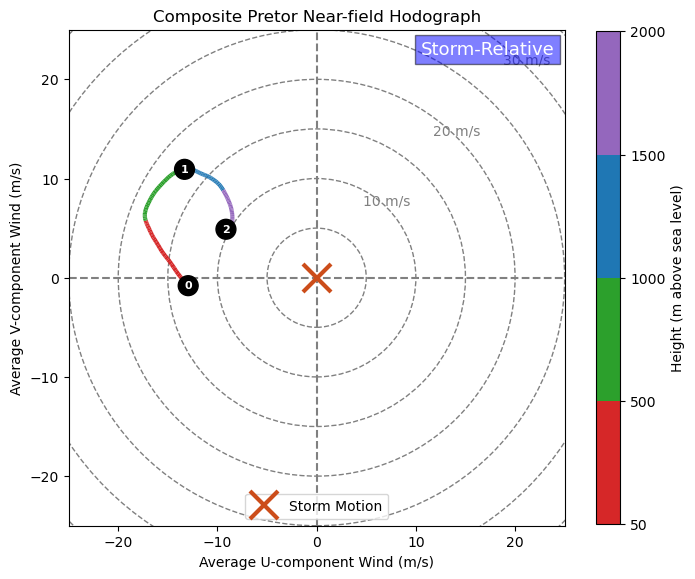

In [131]:
hodo_plot(nontor_nearfield_u, nontor_nearfield_v, nontor_nearfield_heights, 25, 'Composite Pretor Near-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

In [112]:
hodo_plot(tor_farfield_u, tor_farfield_v, tor_farfield_heights, 25, 'Composite Tor Far-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

NameError: name 'tor_farfield_u' is not defined

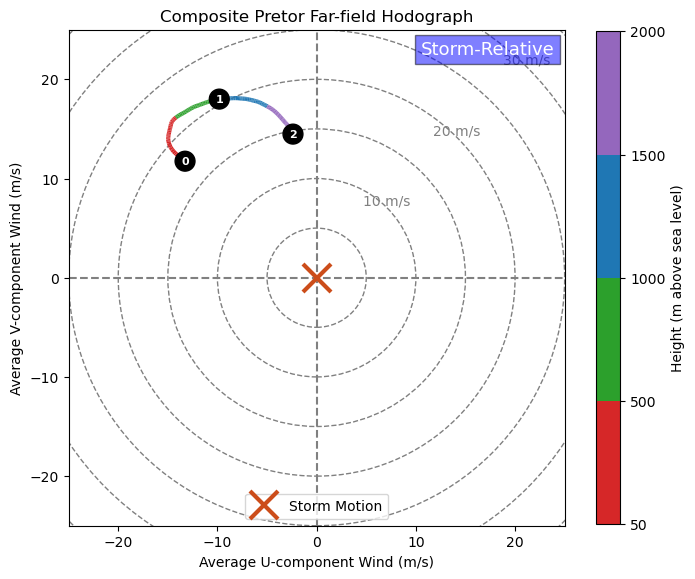

In [132]:
hodo_plot(nontor_farfield_u, nontor_farfield_v, nontor_farfield_heights, 25, 'Composite Pretor Far-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

In [133]:
# Add a label to each variable
def add_label(data, label):
    return pd.DataFrame(data).assign(Variable=label)

In [134]:
#columns = ['NFToru', 'NFTorv', 'FFToru', 'FFTorv', 'NFPreToru', 'NFPreTorv', 'FFPreToru', 'FFPreTorv']
columns = ['NFToru', 'NFTorv', 'NFPreToru', 'NFPreTorv', 'FFPreToru', 'FFPreTorv']
comp_data_uv = [tor_nearfield_u, tor_nearfield_v, nontor_nearfield_u, nontor_nearfield_v,
                nontor_farfield_u, nontor_farfield_v]

comp_field_uv_df = pd.DataFrame(comp_data_uv)
comp_field_uv_df['Variable'] = columns 

In [135]:
comp_field_uv_df

,0,1,2,3,4,5,6,7,8,9,...,187,188,189,190,191,192,193,194,195,Variable
0,-15.213027,-15.351514,-15.481475,-15.547660,-15.619667,-15.915265,-16.086073,-16.407192,-16.562933,-16.911489,...,-11.078469,-11.067773,-11.048926,-11.034111,-11.019570,-11.002357,-10.992198,-10.982018,-10.973330,NFToru
1,-1.843063,-1.672798,-1.501529,-1.355369,-1.331837,-1.006018,-0.864702,-0.583023,-0.433173,-0.202830,...,3.993429,3.981789,3.969449,3.954863,3.943808,3.939207,3.939961,3.941056,3.942655,NFTorv
2,-12.950156,-13.050076,-13.147882,-13.241332,-13.241332,-13.433301,-13.517207,-13.699455,-13.789360,-13.962195,...,-8.848008,-8.879316,-8.919661,-8.952647,-8.990669,-9.032369,-9.065422,-9.110241,-9.143163,NFPreToru
3,-0.801590,-0.711820,-0.604764,-0.496506,-0.496506,-0.288176,-0.175443,0.045139,0.160622,0.390756,...,5.110356,5.079341,5.040944,5.011014,4.978853,4.951838,4.929791,4.904314,4.885677,NFPreTorv
4,-13.267104,-13.388265,-13.522268,-13.636064,-13.646930,-13.861865,-13.963430,-14.174760,-14.284685,-14.431361,...,-2.495670,-2.476514,-2.448562,-2.436923,-2.417959,-2.405316,-2.397835,-2.392596,-2.386075,FFPreToru
5,11.745870,11.838160,11.937305,12.026141,12.032251,12.222508,12.313132,12.488668,12.586882,12.739066,...,14.853102,14.811419,14.761133,14.719581,14.668279,14.616871,14.572671,14.521311,14.477065,FFPreTorv


In [136]:
comp_field_uv_df.to_csv(f'case_dfs/new/{d}_uv_{ka}.csv', index=False)

In [137]:
all_tor_nf_u, all_tor_nf_v =  u_and_v(tor_nearfield_vads, gps, tor_nearfield_velocity, tor_nearfield_bearing)

In [138]:
all_nontor_nf_u, all_nontor_nf_v = u_and_v(nontor_nearfield_vads, gps, nontor_nearfield_velocity, nontor_nearfield_bearing)

In [139]:
all_tor_ff_u, all_tor_ff_v = u_and_v(tor_farfield_vads, gps, tor_farfield_velocity, tor_farfield_bearing)

In [140]:
all_nontor_ff_u, all_nontor_ff_v = u_and_v(nontor_farfield_vads, gps, nontor_farfield_velocity, nontor_farfield_bearing)

In [141]:
columns = ['NFToru', 'NFTorv', 'NFPreToru', 'NFPreTorv', 'FFToru', 'FFTorv', 'FFPreToru', 'FFPreTorv']
data_uv = [all_tor_nf_u, all_tor_nf_v, all_nontor_nf_u, all_nontor_nf_v , all_tor_ff_u, 
                    all_tor_ff_v, all_nontor_ff_u, all_nontor_ff_v]

dfs = []
for v, name in zip(data_uv, columns):
    df = add_label(v, name)
    dfs.append(df)

In [142]:
df_uv = pd.concat([dfs[0], dfs[1], dfs[2], dfs[3], dfs[4], dfs[5], dfs[6], dfs[7]], ignore_index=True)

/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_36730/987637425.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_uv = pd.concat([dfs[0], dfs[1], dfs[2], dfs[3], dfs[4], dfs[5], dfs[6], dfs[7]], ignore_index=True)


In [143]:
df_uv

,0,1,2,3,4,5,6,7,8,9,...,187,188,189,190,191,192,193,194,195,Variable
0,-23.587902,-23.764126,-23.874603,-23.946636,-23.946636,-24.098461,-24.109671,-24.140921,-24.145794,-24.050413,...,11.591532,11.615097,11.646646,11.705799,11.755020,11.838600,11.914471,11.976553,12.025280,NFToru
1,-21.644875,-21.806631,-21.917406,-21.930534,-21.930534,-22.013798,-21.886925,-21.733574,-21.654261,-21.256344,...,12.995554,13.031050,13.144897,13.199759,13.198685,13.329617,13.411972,13.570866,13.643330,NFToru
2,-19.562157,-19.510490,-19.349842,-19.140547,-19.140547,-18.634007,-18.059793,-17.037962,-16.564121,-15.282240,...,13.052049,13.062766,13.055644,13.060515,13.004102,12.976794,12.970767,12.955459,12.923276,NFToru
3,-13.237139,-13.379038,-13.557779,-13.557779,-13.773801,-14.202717,-14.469843,-14.955347,-15.213850,-15.720899,...,-11.442196,-11.426209,-11.398230,-11.382201,-11.357473,-11.326538,-11.309661,-11.290825,-11.286187,NFToru
4,-16.369846,-16.566254,-16.750229,-16.924305,-16.924305,-17.271301,-17.429602,-17.744366,-17.901424,-18.177261,...,-11.209726,-11.199408,-11.177775,-11.166646,-11.154963,-11.147779,-11.139790,-11.135021,-11.132462,NFToru
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,8.951497,9.003158,9.056890,9.121058,9.121058,9.236145,9.274891,9.364758,9.416416,9.497479,...,12.946858,12.932663,12.901108,12.892062,12.835215,12.732039,12.655850,12.532539,12.466708,FFPreTorv
230,7.911753,8.001347,8.098525,8.171608,8.171608,8.312776,8.369843,8.504721,8.569556,8.670777,...,12.620587,12.567372,12.479603,12.400099,12.352266,12.279966,12.253767,12.197875,12.177191,FFPreTorv
231,10.015459,10.162411,10.262675,10.335453,10.335453,10.502072,10.534036,10.621165,10.654132,10.683478,...,15.204228,15.149949,15.050927,14.942026,14.883471,14.771206,14.733883,14.656234,14.611772,FFPreTorv
232,9.731104,9.751983,9.786532,9.812127,9.812127,9.878039,9.930733,10.031611,10.079183,10.221302,...,14.508509,14.497731,14.466092,14.462752,14.421799,14.366920,14.329930,14.243104,14.202951,FFPreTorv


In [144]:
field_uv_all_df = pd.DataFrame(df_uv)
field_uv_all_df.to_csv(f'case_dfs/new/{d}_uv_{ka}_all.csv', index=False)

230528012534
max height 7077.0  meters
min height 0.0  meters


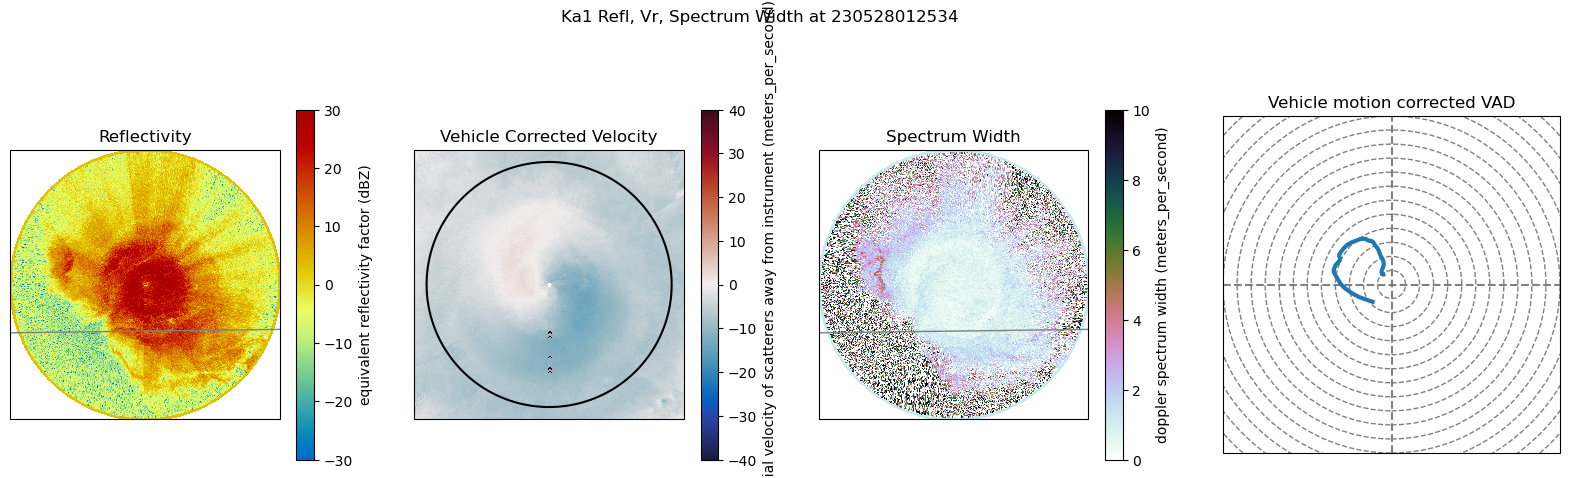

230528012547
max height 7056.0  meters
min height 0.0  meters


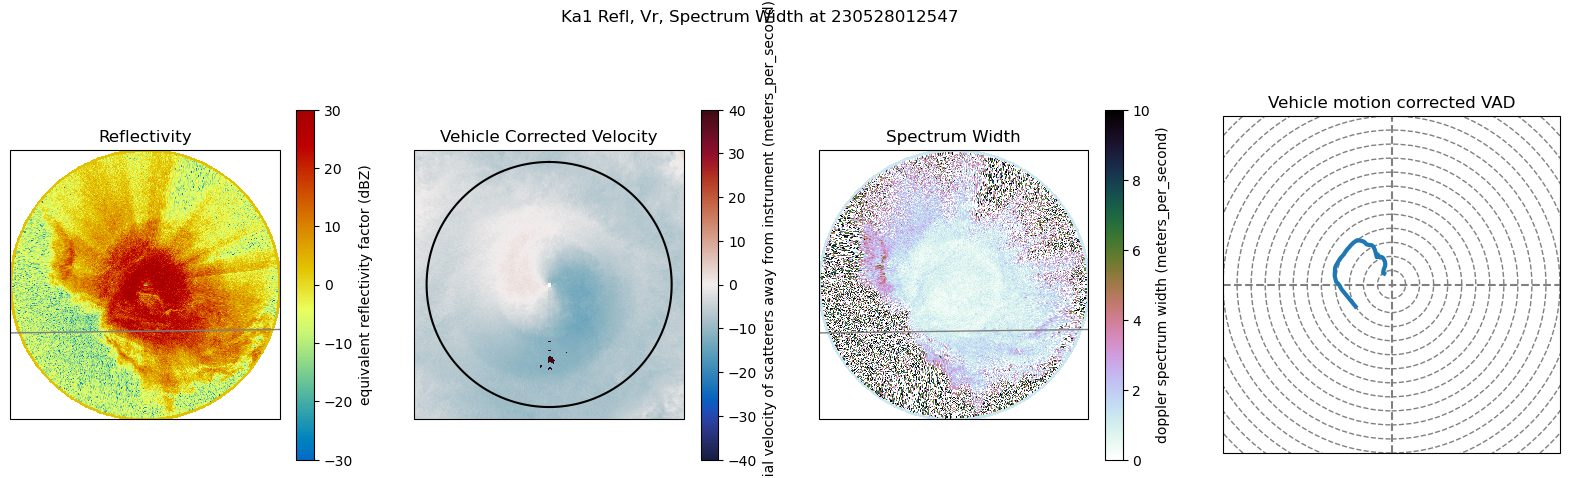

230528012600
max height 7047.0  meters
min height 0.0  meters


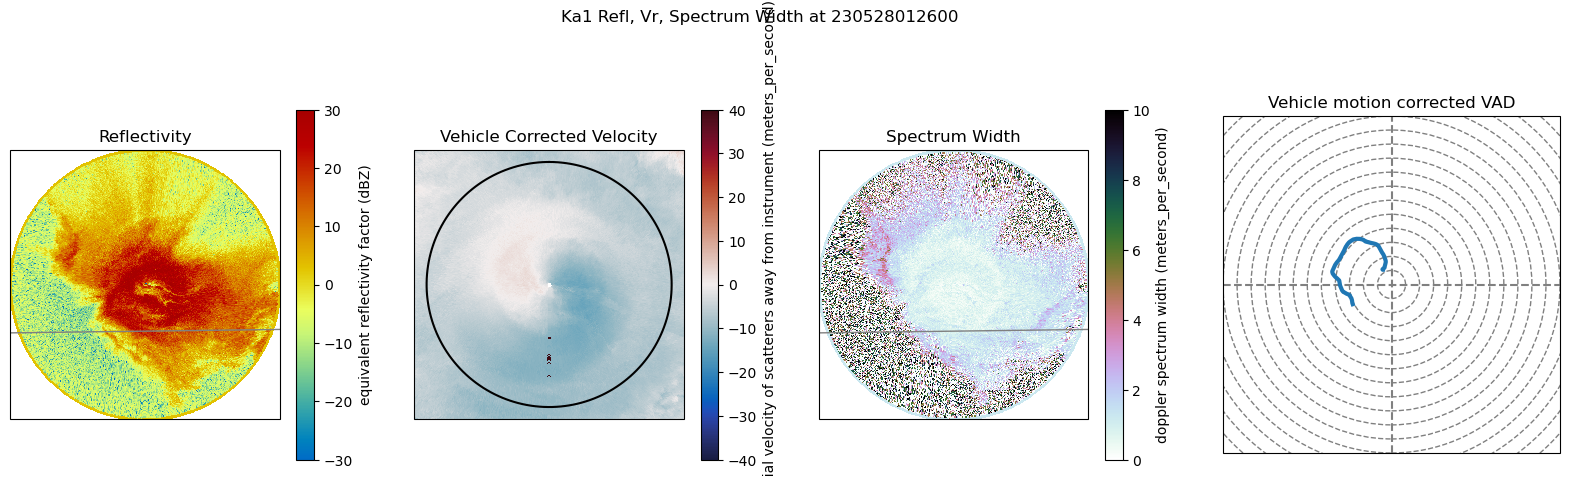

In [128]:
for i in tor_nearfield_vads[3:]: 
    fig = plt.figure(figsize=(20,10))
    read = pyart.io.read(i)
    print(i[-15:-3])
    time = i[-15:-3]
    #print(f'vehicle speed was {ka2_df.Velmean[i]}')
    radar = read.extract_sweeps([0])
    radar, _, _, _, _, _, _, _, _ = vehicle_correction_vad(radar, gps)
    display = pyart.graph.RadarMapDisplay(radar)
    ax1 = fig.add_subplot(2,4,1, projection = display.grid_projection)
    display.plot_ppi_map('reflectivity', ax = ax1, vmin = -30, vmax = 30)
    ax1.set_title('Reflectivity')
    ax2 = fig.add_subplot(2,4,2, projection = display.grid_projection)
    display.plot_ppi_map('vad_corrected_velocity', ax = ax2, 
                         vmin = -40, vmax = 40, cmap = 'pyart_balance')
    display.plot_range_ring(2)
    ax2.set_title('Vehicle Corrected Velocity')
    ax3 = fig.add_subplot(2,4,3, projection = display.grid_projection)
    display.plot_ppi_map('spectrum_width', ax = ax3, cmap = 'cubehelix_r', vmin = 0, vmax = 10)
    ax3.set_title('Spectrum Width')
    ax4 = fig.add_subplot(2,4,4, projection = display.grid_projection)
    ax4.set_xlabel('U-component Wind [knots]')
    ax4.set_ylabel('V-component Wind [knots]')
    ax4.set_title('Vehicle motion corrected VAD')
    VAD = pyart.retrieve.vad_browning(radar, 'vad_corrected_velocity', z_want=np.arange(50,2001,10),gatefilter=None)
    vadu = VAD.u_wind*1.94384 # meters to knots
    vadv = VAD.v_wind*1.94384
    hodo = metpy.plots.Hodograph(ax4, component_range=60.)
    hodo.add_grid(increment=5)
    hodo.plot(vadu, vadv)
    plt.suptitle(f'{Ka} Refl, Vr, Spectrum Width at {time}')
    plt.show()

# Old

In [ ]:
columns = ['NFToru', 'NFTorv', 'NFNonToru', 'NFNonTorv', 'FFToru', 'FFTorv', 'FFNonToru', 'FFNonTorv']
data = np.array([tor_nearfield_u, tor_nearfield_v, nontor_nearfield_u, nontor_nearfield_v, tor_farfield_u, 
tor_farfield_v, nontor_farfield_u, nontor_farfield_v]).T

# data = np.array([tor_nearfield_u, tor_nearfield_v, tor_farfield_u, 
# tor_farfield_v, nontor_farfield_u, nontor_farfield_v]).T


field_uv_df = pd.DataFrame(data, columns = columns)
# field_uv_df.insert(3, 'NFNonToru', None)
# field_uv_df.insert(4, 'NFNonTorv', None)
field_uv_df.to_csv(f'{d}_uv_{ka}.csv', index=False)


In [ ]:
field_uv_df

In [ ]:
# field_uv_df = pd.DataFrame(np.array([nontor_farfield_u, nontor_farfield_v]).T, columns=['FFNonToru','FFNonTorv'])
# field_uv_df.to_csv(f'{d}_uv_{ka}.csv', index=False)

In [ ]:
nearfield_vad_times, nearfield_times, nearfield_indeces, nearfield_lats, nearfield_lons = nearest_tobac_time(nearfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])

In [ ]:
nearfield_bearing = storm_bearing[nearfield_indeces]
nearfield_velocity = storm_speed[nearfield_indeces]

In [ ]:
farfield_vad_times, farfield_times, farfield_indeces, farfield_lats, farfield_lons = nearest_tobac_time(farfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])

In [ ]:
farfield_bearing = storm_bearing[farfield_indeces]
farfield_velocity = storm_speed[farfield_indeces]

In [ ]:
nearfield_u, nearfield_v, nearfield_heights = composite_u_and_v(nearfield_vads, gps, nearfield_velocity, nearfield_bearing)

In [ ]:
farfield_u, farfield_v, farfield_heights = composite_u_and_v(farfield_vads, gps, farfield_velocity, farfield_bearing)

In [ ]:
from matplotlib import rcParams, rcParamsDefault
title = 'Composite Near-field Hodograph'
rcParams.update(rcParamsDefault)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
hodo = metpy.plots.Hodograph(ax, component_range=25.)
hodo.add_grid(increment=5)

for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
    x = speed / np.sqrt(2)
    y = speed / np.sqrt(2)
    ax.text(x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')

colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple']
#colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
boundaries = [50, 500, 1000, 1500, 2000]

h = hodo.plot_colormapped(nearfield_u, nearfield_v, nearfield_heights, intervals=boundaries, colors=colors)
# hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
# hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
# hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])

#ax.scatter(0,0, 'ko')
ax.set_xlabel('Average U-component Wind (m/s)')
ax.set_ylabel('Average V-component Wind (m/s)')
ax.set_title(f'{title}')
for i,z in enumerate([0,95,195,295,395,495]):
    try:
        if np.isnan(nearfield_u[z]):
            pass
        else:
            circle = plt.Circle((nearfield_u[z], nearfield_v[z]), radius=1,color='k',zorder=30)
            ax.add_patch(circle)
            label = ax.annotate(i, xy=(nearfield_u[z], nearfield_v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
    except: pass

ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)

plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = [0.8,0.3,0.1,1], markeredgewidth = 3)
plt.legend(loc='lower center')
#plt.savefig('/Users/juliabman/Desktop/GradyCompNearfield_novort')
plt.show()

In [ ]:
from matplotlib import rcParams, rcParamsDefault
title = 'Composite Near-field Hodograph'
rcParams.update(rcParamsDefault)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
hodo = metpy.plots.Hodograph(ax, component_range=25.)
hodo.add_grid(increment=5)

for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
    x = speed / np.sqrt(2)
    y = speed / np.sqrt(2)
    ax.text(x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')

colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple']
#colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
boundaries = [50, 500, 1000, 1500, 2000]

h = hodo.plot_colormapped(farfield_u, farfield_v, farfield_heights, intervals=boundaries, colors=colors)
# hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
# hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
# hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])

#ax.scatter(0,0, 'ko')
ax.set_xlabel('Average U-component Wind (m/s)')
ax.set_ylabel('Average V-component Wind (m/s)')
ax.set_title(f'{title}')
for i,z in enumerate([0,95,195,295,395,495]):
    try:
        if np.isnan(farfield_u[z]):
            pass
        else:
            circle = plt.Circle((farfield_u[z], farfield_v[z]), radius=1,color='k',zorder=30)
            ax.add_patch(circle)
            label = ax.annotate(i, xy=(farfield_u[z], farfield_v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
    except: pass

ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)

plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = [0.8,0.3,0.1,1], markeredgewidth = 3)
plt.legend(loc='lower center')
#plt.savefig('/Users/juliabman/Desktop/GradyCompNearfield_novort')
plt.show()

In [ ]:
tor_vads = vad_df[vad_df.Tor == 'during tor']
tor_id = tor_vads.index.values
tor_vads = [easterlies_vads[i] for i in tor_id]

In [ ]:
tor_times, tor_times, tor_indeces, tor_lats, tor_lons = nearest_tobac_time(tor_vads, np.array(latitude_weighted_tobac),
                                                                                     np.array(longitude_weighted_tobac),
                                                                                     storm_times[:-1])
tor_bearing = storm_bearing[tor_indeces]
tor_velocity = storm_speed[tor_indeces]

In [ ]:
tor_u, tor_v, tor_heights = composite_u_and_v(tor_vads, gps, tor_velocity, tor_bearing)

In [ ]:
from matplotlib import rcParams, rcParamsDefault
title = 'Composite During Tornadogenesis Hodograph'
rcParams.update(rcParamsDefault)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
hodo = metpy.plots.Hodograph(ax, component_range=25.)
hodo.add_grid(increment=5)

for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
    x = speed / np.sqrt(2)
    y = speed / np.sqrt(2)
    ax.text(x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')

colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple']
boundaries = [50, 500, 1000, 1500, 2000]

h = hodo.plot_colormapped(tor_u, tor_v, tor_heights, intervals=boundaries, colors=colors)
# hodo.wind_vectors(tor_u_plains[0], tor_v_plains[0], label = 'Storm_Relative Wind Vector (m/s)')
# hodo.wind_vectors(tor_u_plains[99], tor_v_plains[99])
# #hodo.wind_vectors(tor_u_plains[195], tor_v_plains[195])

#ax.scatter(0,0, 'ko')
ax.set_xlabel('Average U-component Wind (m/s)')
ax.set_ylabel('Average V-component Wind (m/s)')
ax.set_title(f'{title}')
for i,z in enumerate([0,95,195,295,395,495]):
    try:
        if np.isnan(tor_u[z]):
            pass
        else:
            circle = plt.Circle((tor_u[z], tor_v[z]), radius=1,color='k',zorder=30)
            ax.add_patch(circle)
            label = ax.annotate(i, xy=(tor_u[z], tor_v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
    except: pass

ax.text(0.71, 0.94, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='bottom', color='white', bbox=dict(facecolor='blue', alpha=0.5))
plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = [0.8,0.3,0.1,1], markeredgewidth = 3)
plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
# plt.ylim(-30, 55)
# plt.xlim(-55, 30)
plt.legend(loc='lower center')
#plt.savefig('/Users/juliabman/Desktop/SLS Images/plainsPreTorComp25_novortlow')
plt.show()

In [ ]:
np.shape(easterlies_vads)

In [ ]:
for i in easterlies_vads: 
    fig = plt.figure(figsize=(20,10))
    read = pyart.io.read(i)
    print(i[-15:-3])
    time = i[-15:-3]
    #print(f'vehicle speed was {ka2_df.Velmean[i]}')
    radar = read.extract_sweeps([0])
    radar, _, _, _, _, _, _, _, _ = vehicle_correction_vad(radar, gps)
    display = pyart.graph.RadarMapDisplay(radar)
    ax1 = fig.add_subplot(2,4,1, projection = display.grid_projection)
    display.plot_ppi_map('reflectivity', ax = ax1, vmin = -30, vmax = 30)
    ax1.set_title('Reflectivity')
    ax2 = fig.add_subplot(2,4,2, projection = display.grid_projection)
    display.plot_ppi_map('vad_corrected_velocity', ax = ax2, 
                         vmin = -40, vmax = 40, cmap = 'pyart_balance')
    display.plot_range_ring(2)
    ax2.set_title('Vehicle Corrected Velocity')
    ax3 = fig.add_subplot(2,4,3, projection = display.grid_projection)
    display.plot_ppi_map('spectrum_width', ax = ax3, cmap = 'cubehelix_r', vmin = 0, vmax = 10)
    ax3.set_title('Spectrum Width')
    ax4 = fig.add_subplot(2,4,4, projection = display.grid_projection)
    ax4.set_xlabel('U-component Wind [knots]')
    ax4.set_ylabel('V-component Wind [knots]')
    ax4.set_title('Vehicle motion corrected VAD')
    VAD = pyart.retrieve.vad_browning(radar, 'vad_corrected_velocity', z_want=np.arange(50,2001,10),gatefilter=None)
    vadu = VAD.u_wind*1.94384 # meters to knots
    vadv = VAD.v_wind*1.94384
    hodo = metpy.plots.Hodograph(ax4, component_range=60.)
    hodo.add_grid(increment=5)
    hodo.plot(vadu, vadv)
    plt.suptitle(f'{Ka} Refl, Vr, Spectrum Width at {time}')
    plt.show()